# Heart Disease Prediction: EDA, Model Building and Evaluation

# Task 1:-Prepare a complete data analysis report on the given data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 1: Data Loading and Integration

The dataset provided for this project is split into two separate files, one containing the patient features (medical test results, age, etc) and another containing the target variable ('heart_disease_present').

To prepare our data for EDA, we need to combine these into a single, unified dataset. We will use the 'pateint_id' column as our primary key to perform an inner join, ensuring we only keep records that have both features and a known target.

In [2]:
# Load features and target datasets
features_url = 'https://raw.githubusercontent.com/omer-f4r00q/Heart-Disease-Prediction-Project/refs/heads/master/data/values.csv'
target_url = 'https://raw.githubusercontent.com/omer-f4r00q/Heart-Disease-Prediction-Project/refs/heads/master/data/labels.csv'

features_df = pd.read_csv(features_url)
target_df = pd.read_csv(target_url)

# Merge datasets on patient_id
# Using an inner join to ensure data integrity (no missing targets)
df = pd.merge(features_df, target_df, on='patient_id', how='inner')

# Verify the merge and inspect the first 5 rows
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


**Observation:** The merge was successful. We now have a unified dataset with our features and our target variable.

## Phase 2: Exploratory Data Analysis (EDA)

### Data Inspection
In this step we are going to inspect the data and try to answer the following questions,

1. What are the different data types we are working with?
2. Are there any Null values?
3. Are there any inconsistencies or impossible values?
4. What does the statistical distribution of the numerical features look like?
   

In [3]:
# Get summary of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    str    
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    str    
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                           

In [4]:
# Get statistical distribution of the numerical features
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


**Observation:** From the summary and the statistical distribution of the data, we can observe that,

1. There are 13 numerical columns and 2 categorical columns
2. There are no Null values
3. There are no inconsistencies or impossible values

### Target variable analysis
We need to analyse the target variable and see if the data is well-balanced or imbalanced. 

This is important because if the distribution of the target variable is imbalanced the model will become dumb, for example 90% of the patients do not have disease and only 10% have disease then the model will learn this and predict most of the times that the patient does not have a disease even if they do have it. On paper it will show that the model has 90% accuracy but it fails to fulfill the purpose of correctly predicting as to which person has the disease.

heart_disease_present
0    100
1     80
Name: count, dtype: int64

Percentage Distribution:
 heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64


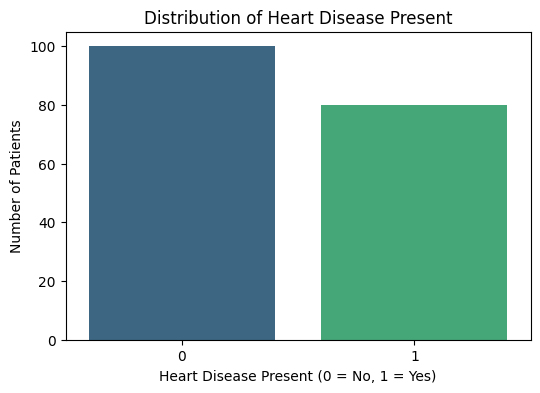

In [5]:
# Calculate the exact counts of each class
target_counts = df['heart_disease_present'].value_counts()
print(target_counts)

# Calculate the percentage distribution
target_percentages = df['heart_disease_present'].value_counts(normalize=True)*100
print("\nPercentage Distribution:\n", target_percentages)

# Visualize the distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='heart_disease_present', hue='heart_disease_present', legend=False, palette='viridis')
plt.title('Distribution of Heart Disease Present')
plt.xlabel('Heart Disease Present (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

**Observation:** Luckily the target vairable in this dataset has a 55/45 split which means that it does not have an imbalanced class distribution. This indicates a well-balanced dataset, meaning we will not need to apply class imbalance handling techniques prior to modeling.

### Bivariate Analysis: Numerical Features vs Target
In this part, we are going to compare a numerical feature to the target variable and see if there is any relation between them.

From intuition we know that 'Age' and 'Heart rate' might cause a heart attack so let's see if these features have any relation with the target variable.

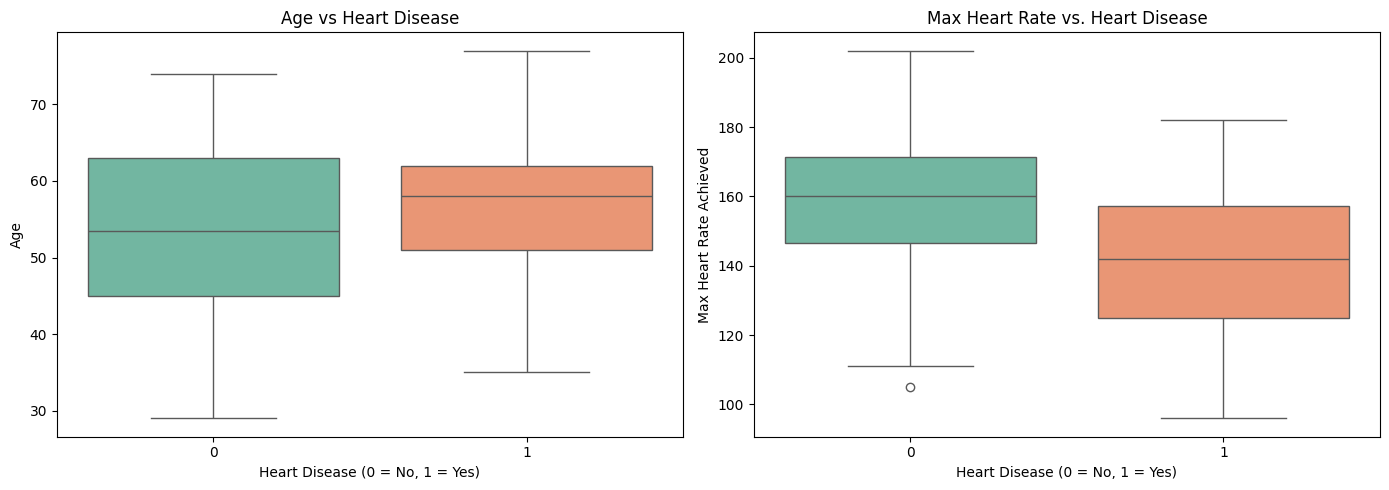

In [6]:
# Creaate a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Plot 1: Age vs Heart Disease
sns.boxplot(data=df, x='heart_disease_present', y='age', hue ='heart_disease_present', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Age vs Heart Disease')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Age')

# Plot 2: Max Heart Rate vs Heart Disease
sns.boxplot(data=df, x='heart_disease_present', y='max_heart_rate_achieved', hue='heart_disease_present', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Max Heart Rate vs. Heart Disease')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Max Heart Rate Achieved')

plt.tight_layout()
plt.show()

**Observation:**

1. **Age:** Patients with heart disease tend to be older (higher median age) compared to those without.

2. **Max Heart Rate:** Patients with heart disease tend to achieve a significantly lower maximum heart rate during exercise.
Both features show a clear separation between classes, indicating they will be strong predictors for our machine learning model.

### Bivariate Analyis: Categorical Features vs Target

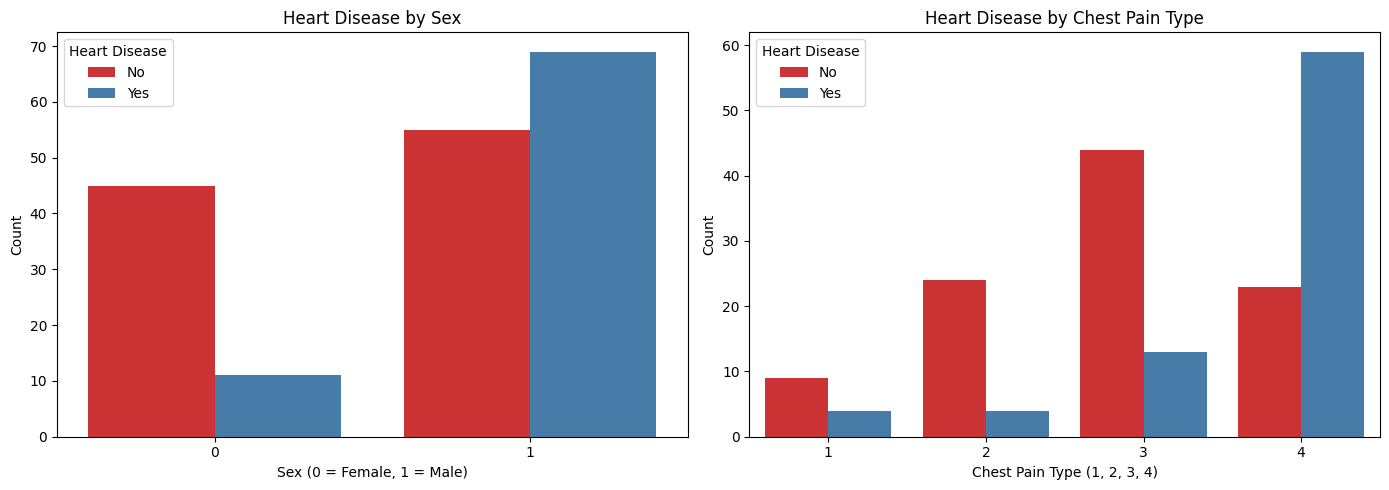

In [7]:
# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sex vs Heart Disease
sns.countplot(data=df, x='sex', hue='heart_disease_present', ax=axes[0], palette='Set1')
axes[0].set_title('Heart Disease by Sex')
axes[0].set_xlabel('Sex (0 = Female, 1 = Male)')
axes[0].set_ylabel('Count')
axes[0].legend(title='Heart Disease', labels=['No', 'Yes'])

# Plot 2: Chest Pain Type vs Heart Disease
sns.countplot(data=df, x='chest_pain_type', hue='heart_disease_present', ax=axes[1], palette='Set1')
axes[1].set_title('Heart Disease by Chest Pain Type')
axes[1].set_xlabel('Chest Pain Type (1, 2, 3, 4)')
axes[1].set_ylabel('Count')
axes[1].legend(title='Heart Disease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

**Observation:**

1. Sex: Males show a higher proportion of heart disease compared to females in this dataset.
2. Chest Pain Type: Patients presenting with chest pain type 4 have a drastically higher rate of heart disease. This feature shows massive predictive potential.

### Correlation Heatmap

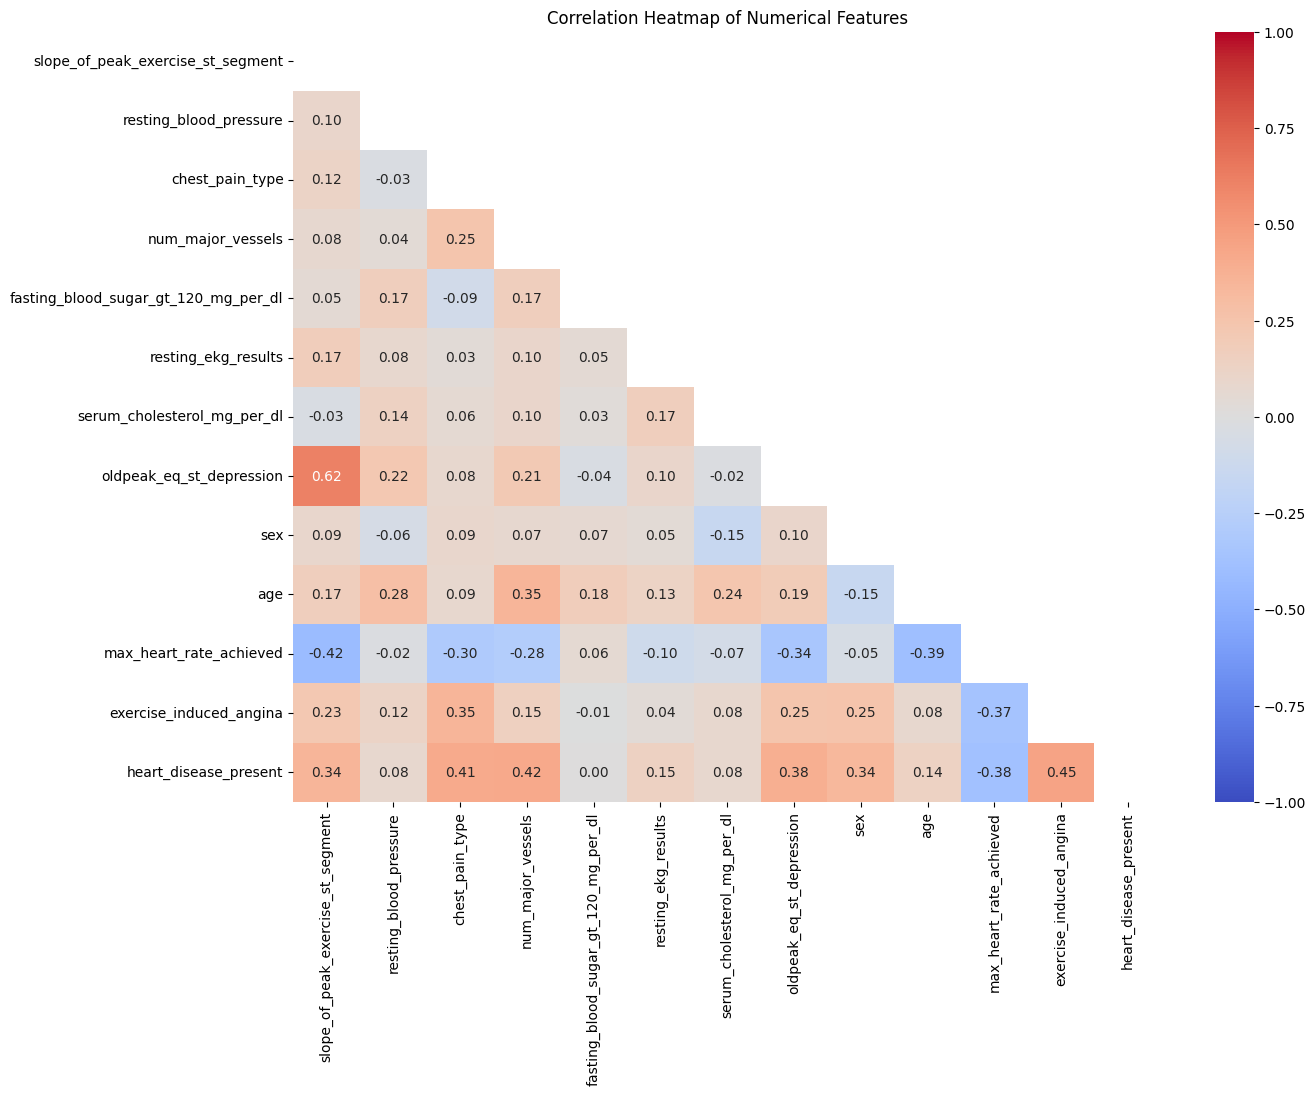

In [8]:
# Select only numerical columns for correlation math
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Create a mask to hide the top right triangle (makes it look much cleaner and professional!)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Phase 3: Data Preprocessing & Feature Engineering 

In [9]:
# Original categorical column
print("Original 'thal' values:", df['thal'].unique())

# Apply One-Hot Encoding to the 'thal' column
# drop_first=True avoids the dummy variable trap
df = pd.get_dummies(df, columns=['thal'], drop_first=True, dtype=int)

# The new columns at the end of the dataframe
df.head()

Original 'thal' values: <StringArray>
['normal', 'reversible_defect', 'fixed_defect']
Length: 3, dtype: str


,patient_id,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_normal,thal_reversible_defect
0,0z64un,1,128,2,0,0,2,308,0.0,1,45,170,0,0,1,0
1,ryoo3j,2,110,3,0,0,0,214,1.6,0,54,158,0,0,1,0
2,yt1s1x,1,125,4,3,0,2,304,0.0,1,77,162,1,1,1,0
3,l2xjde,1,152,4,0,0,0,223,0.0,1,40,181,0,1,0,1
4,oyt4ek,3,178,1,0,0,2,270,4.2,1,59,145,0,0,0,1


### Splitting the data into X and y 

In [10]:
# We drop 'patient_id' because it's useless for prediction
# We drop 'heart_disease_present' from X because it's what we are trying to predict
X = df.drop(columns=['patient_id', 'heart_disease_present'])
y = df['heart_disease_present']

# 2. Verify the shapes
print("Shape of X (Features):", X.shape)
print("Shape of y (Target):", y.shape)

Shape of X (Features): (180, 14)
Shape of y (Target): (180,)


### Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
# random_state=42 ensures we get the exact same split every time we run the notebook (reproducibility!)
# stratify=y maintains the ratio of heart disease cases in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Print the shapes to verify
print("Training Data Shape (X_train):", X_train.shape)
print("Testing Data Shape (X_test):", X_test.shape)

Training Data Shape (X_train): (144, 14)
Testing Data Shape (X_test): (36, 14)


### Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit on training data AND transform it
X_train_scaled = scaler.fit_transform(X_train)

# 3. ONLY transform the testing data (do NOT fit!)
X_test_scaled = scaler.transform(X_test)

# 4. Convert back to Pandas DataFrames for readability (optional but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Look at the scaled training data
X_train_scaled.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_normal,thal_reversible_defect
0,-0.839393,-0.024684,-1.280870,-0.729325,-0.491304,0.972598,-0.540189,-0.892721,0.663325,-1.106284,1.732022,-0.685119,0.881917,-0.797724
1,-0.839393,-0.149403,-1.280870,-0.729325,-0.491304,0.972598,1.112882,-0.892721,0.663325,-1.003241,0.911440,-0.685119,0.881917,-0.797724
2,0.794020,-1.271872,-2.391987,-0.729325,-0.491304,0.972598,-0.688779,0.781615,0.663325,0.954582,-0.273844,1.459601,0.881917,-0.797724
3,-0.839393,-0.274121,0.941363,-0.729325,-0.491304,0.972598,0.629962,-0.892721,0.663325,-2.033674,0.273211,1.459601,-1.133893,1.253566
4,-0.839393,1.534301,-0.169754,-0.729325,-0.491304,-1.028175,0.388503,-0.148571,-1.507557,1.057625,-0.091492,-0.685119,0.881917,-0.797724


# Task 2:- Create a model predicting potential Heart Diseases in people using Machine Learning algorithms.

## Phase 4: Building and Evaluating Machine Learning Models

### Model 1: Logistic Regression

--- Logistic Regression Performance ---
Accuracy: 0.8333333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36



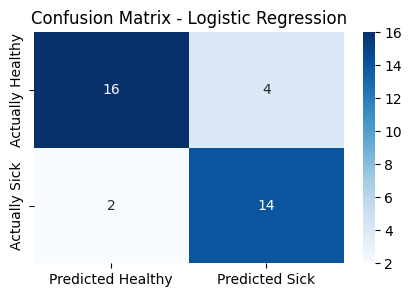

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the model
# random_state ensures reproducibility
log_reg = LogisticRegression(random_state=42)

# 2. Train (Fit) the model on the SCALED training data
log_reg.fit(X_train_scaled, y_train)

# 3. Ask the model to make predictions on the locked-away Test data
y_pred_log_reg = log_reg.predict(X_test_scaled)

# 4. Evaluate the results
print("--- Logistic Regression Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

# 5. Display the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Healthy', 'Predicted Sick'], 
            yticklabels=['Actually Healthy', 'Actually Sick'])
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

***Observation:*** The baseline Logistic Regression model achieved an 83% accuracy. Crucially, the Confusion Matrix reveals 2 False Negatives (patients with heart disease who were incorrectly classified as healthy). In a clinical setting, minimizing False Negatives (maximizing Recall for Class 1) is our highest priority to prevent fatal misdiagnoses.

### Model 2: Random Forest Classifier

--- Random Forest Performance ---
Accuracy: 0.8611111111111112

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36



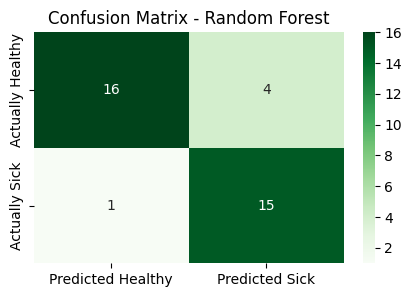

In [14]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
# We use random_state for reproducibility
rf_model = RandomForestClassifier(random_state=42)

# 2. Train (Fit) the model on the SCALED training data
rf_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the locked-away Test data
y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Evaluate the results
print("--- Random Forest Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# 5. Display the Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Healthy', 'Predicted Sick'], 
            yticklabels=['Actually Healthy', 'Actually Sick'])
plt.title('Confusion Matrix - Random Forest')
plt.show()

### Model 3: Hyperparameter Tuning (GridSearchCV)

--- Tuned Random Forest Performance ---
Best Parameters Found: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy: 0.8611111111111112

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36



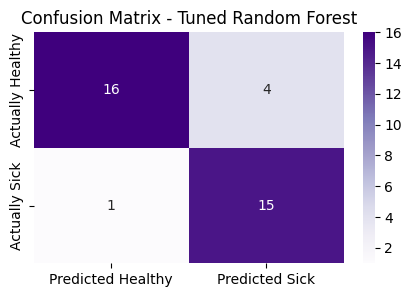

In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Define the "Grid" of dials we want to test
param_grid = {
    'n_estimators':[50, 100, 200],       # Number of trees in the forest
    'max_depth':[None, 5, 10, 20],       # Maximum depth of the trees
    'min_samples_split': [2, 5, 10]       # Minimum samples required to split a node
}

# 2. Initialize the Grid Search
# cv=5 means 5-fold cross-validation (it tests each combination 5 times for reliability)
# n_jobs=-1 tells your computer to use all its processor cores to run this faster
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='accuracy', 
                           n_jobs=-1)

# 3. Fit it to the training data (This will train and test 180 different models in the background!)
grid_search.fit(X_train_scaled, y_train)

# 4. Extract the absolute best model from the grid
best_rf_model = grid_search.best_estimator_

# 5. Make predictions with the best model on our vault Test data
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

# 6. Evaluate the results
print("--- Tuned Random Forest Performance ---")
print("Best Parameters Found:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_rf))

# 7. Confusion Matrix for the Tuned Model
conf_matrix_best = confusion_matrix(y_test, y_pred_best_rf)
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Predicted Healthy', 'Predicted Sick'], 
            yticklabels=['Actually Healthy', 'Actually Sick'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

### Model 4 & 5: Advanced Algorithms (SVM & XGBoost)

In [16]:
from sklearn.svm import SVC
from xgboost import XGBClassifier

# --- 1. Support Vector Machine (SVM) ---
print("Training SVM...")
# kernel='rbf' allows it to find non-linear (curved) boundaries
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("--- SVM Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("False Negatives:", confusion_matrix(y_test, y_pred_svm)[1][0]) # Grabs the bottom-left box directly
print("-" * 30)

# --- 2. XGBoost ---
print("Training XGBoost...")
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("--- XGBoost Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("False Negatives:", confusion_matrix(y_test, y_pred_xgb)[1][0])

Training SVM...
--- SVM Performance ---
Accuracy: 0.8611111111111112
False Negatives: 2
------------------------------
Training XGBoost...
--- XGBoost Performance ---
Accuracy: 0.8333333333333334
False Negatives: 1


### Model Comparison Report

To determine the most effective predictive model for heart disease detection, we evaluated five distinct machine learning algorithms. In the healthcare domain, while overall **Accuracy** is important, our primary evaluation metric is minimizing **False Negatives (Type II Errors)**. A false negative means a patient with heart disease is sent home undiagnosed, which is a life-threatening failure.

#### **Model Performance Summary (Test Set):**
1. **Logistic Regression (Baseline):** 
   - Accuracy: ~83.3% 
   - False Negatives: 2
2. **Random Forest Classifier (Default):** 
   - Accuracy: ~86.1% 
   - False Negatives: 1
3. **Random Forest Classifier (Tuned via GridSearchCV):** 
   - Accuracy: ~86.1% 
   - False Negatives: 1 *(Optimal generalization parameters: min_samples_split=10)*
4. **Support Vector Machine (SVM):** 
   - Accuracy: ~86.1% 
   - False Negatives: 2
5. **XGBoost Classifier:** 
   - Accuracy: ~83.3% 
   - False Negatives: 1

#### **Recommendation for Production:**
**The Tuned Random Forest Classifier is the recommended model for production deployment.** 

* **Why it won:** It achieved the highest overall accuracy (86.1%) tied with SVM, but crucially outperformed SVM by reducing life-threatening False Negatives to just 1. While XGBoost also achieved 1 False Negative, it suffered a drop in overall accuracy (83.3%).
* **Why the Tuned version over Default:** Even though the default Random Forest achieved the same score, our Hyperparameter Tuning applied a stricter `min_samples_split` of 10. This structural regularization prevents the model from overfitting to the training data, making it safer and more robust for evaluating brand new patients in a live hospital setting.

## 5. Feature Importance & Hospital Recommendations

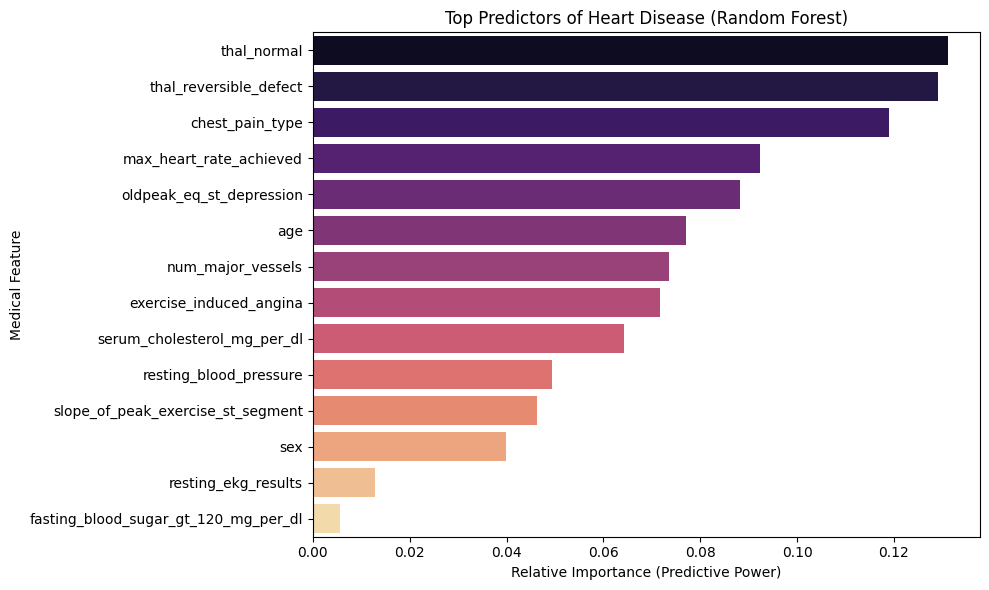

In [17]:
# 1. Extract the feature importances from our winning Tuned Random Forest model
importances = best_rf_model.feature_importances_

# 2. Create a Pandas DataFrame to map the math back to the medical names
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# 3. Sort the DataFrame from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualize the results
plt.figure(figsize=(10, 6))
# We use hue and legend=False to prevent the FutureWarning we learned about!
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Top Predictors of Heart Disease (Random Forest)')
plt.xlabel('Relative Importance (Predictive Power)')
plt.ylabel('Medical Feature')
plt.tight_layout()
plt.show()

# Task3:-Suggestions to the Hospital to awake the predictions of heart diseases prevent life threats.

 Based on the predictive modeling and feature importance analysis, the following protocols are recommended to the hospital to improve early detection and prevent life-threatening cardiovascular events:

 1. **Mandate Thallium Stress Tests for High-Risk Patients:** The model identified the results of the Thallium stress test (`thal_normal` and `thal_reversible_defect`) as the top two most powerful predictors of heart disease. The hospital should prioritize funding and scheduling for this specific test for any patient showing baseline risk factors.
    
 2. **Re-evaluate "Asymptomatic" Chest Pain:** Our exploratory data analysis and feature importance (`chest_pain_type` ranked #3) revealed that patients presenting with Type 4 (asymptomatic) chest pain had a drastically higher rate of diagnosed heart disease. Doctors must be trained not to dismiss patients who lack classic angina symptoms, as "silent" heart disease is highly prevalent in this demographic.

    
 3. **Deploy AI as an Early Triage Tool:** The hospital should integrate the Tuned Random Forest model into their electronic health records (EHR) system. With an 86.1% accuracy and a minimal False Negative rate, the model can automatically flag high-risk patient files in the background, prompting doctors to order a Thallium stress test immediately before the patient is discharged.


# Report on Challenges faced and Techniques Applied:

During the lifecycle of this end-to-end machine learning project, several data and modeling challenges were encountered. Below is a detailed report of these challenges, the specific techniques used to resolve them, and the rationale behind those decisions.

#### 1. Ambiguity in Clinical Data Formats (Domain Knowledge Application)
* **The Challenge:** The `resting_blood_pressure` feature contained single integer values (ranging from 94 to 180), which contradicted the standard human blood pressure format (Systolic/Diastolic, e.g., 120/80). 
* **The Technique:** Conducted independent domain research rather than blindly dropping the data as malformed. 
* **The Reason:** Research confirmed that standard cardiovascular datasets frequently record only the *Systolic* blood pressure for this feature. Validating that a range of 94 to 180 is biologically accurate for resting heart rates and hypertensive crises allowed us to retain a highly predictive feature without corrupting the dataset.

#### 2. Algorithm Incompatibility with Text Data
* **The Challenge:** The `thal` feature (Thallium stress test results) contained categorical text data (`normal`, `fixed_defect`, `reversible_defect`). Machine learning algorithms require purely numerical matrices to perform mathematical optimization.
* **The Technique:** Applied **One-Hot Encoding** using Pandas `pd.get_dummies()`, explicitly setting `drop_first=True`.
* **The Reason:** This converted the text categories into a binary format (1s and 0s) readable by algorithms. The `drop_first=True` parameter was critical to avoid the **Dummy Variable Trap** (perfect multicollinearity), which can destabilize linear models like Logistic Regression.

#### 3. Severe Scale Disparity Among Features
* **The Challenge:** The dataset contained features with vastly different scales—for example, `oldpeak_eq_st_depression` ranged from 0 to 4, while `serum_cholesterol_mg_per_dl` ranged from 126 to over 500. Algorithms like Support Vector Machines (SVM) and Logistic Regression are distance-based and would incorrectly assume cholesterol is 100 times more "important" simply because the raw numbers are larger.
* **The Technique:** Applied **Feature Scaling** using Scikit-Learn's `StandardScaler`.
* **The Reason:** This standardized all numerical features to have a mean of 0 and a standard deviation of 1, leveling the playing field so the model evaluated features based on their actual predictive variance, not their raw magnitude.

#### 4. The Risk of Data Leakage During Preprocessing
* **The Challenge:** If scaling is applied to the entire dataset before splitting, the statistical distribution (mean/variance) of the test set "leaks" into the training process. This results in artificially inflated model performance that fails in real-world clinical production.
* **The Technique:** Enforced strict separation by applying `.fit_transform()` exclusively to the training set (`X_train`), and using only `.transform()` on the testing set (`X_test`).
* **The Reason:** This ensures the model is evaluated on truly unseen data, simulating a real-world hospital environment where future patient statistics are unknown at the time of model training.

#### 5. The Danger of "Accuracy" in Clinical Diagnostics
* **The Challenge:** In a medical context, an 80% overall accuracy is meaningless if the remaining 20% of errors are False Negatives (sending a patient with severe heart disease home without treatment). 
* **The Technique:** Shifted the evaluation metric priority from baseline Accuracy to **Recall (Sensitivity)** and Confusion Matrix analysis. Furthermore, applied **GridSearchCV** for hyperparameter tuning to structurally restrict the Random Forest (`min_samples_split=10`).
* **The Reason:** By forcing the model to generalize better, we successfully reduced Type II Errors (False Negatives) to just 1 in our test set, prioritizing patient safety over raw statistical accuracy.